In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [31]:
data_dir = "AutismDataset"

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [32]:
train_data = ImageFolder(root=f"{data_dir}/train", transform=transform)
val_data = ImageFolder(root=f"{data_dir}/valid", transform=transform)
test_data = ImageFolder(root=f"{data_dir}/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

print("Classes:", train_data.classes)
print("Class-to-index mapping:", train_data.class_to_idx)
print("Total training images:", len(train_data))


Classes: ['Autistic', 'NonAutistic']
Class-to-index mapping: {'Autistic': 0, 'NonAutistic': 1}
Total training images: 2540


In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [34]:
def train_model(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            predicted = (torch.sigmoid(outputs) > 0.5).int()
            correct += (predicted == labels.int()).sum().item()
            total += labels.size(0)

        acc = correct / total * 100
        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Train Acc: {acc:.2f}%")

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                outputs = model(inputs)
                predicted = (torch.sigmoid(outputs) > 0.5).int()
                val_correct += (predicted == labels.int()).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total * 100
        print(f"Validation Acc: {val_acc:.2f}%\n")


In [35]:
def evaluate(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).int()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
    print(f"Test Accuracy: {acc:.2f}%")
    return all_labels, all_preds, all_probs

In [36]:
def plot_confusion_and_report(y_true, y_pred, class_names):
    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


Epoch 1/5 - Loss: 0.4219 - Train Acc: 79.72%
Validation Acc: 76.00%

Epoch 2/5 - Loss: 0.1282 - Train Acc: 95.67%
Validation Acc: 82.00%

Epoch 3/5 - Loss: 0.0446 - Train Acc: 98.82%
Validation Acc: 83.00%

Epoch 4/5 - Loss: 0.0180 - Train Acc: 99.72%
Validation Acc: 81.00%

Epoch 5/5 - Loss: 0.0112 - Train Acc: 99.80%
Validation Acc: 78.00%

Test Accuracy: 89.33%
              precision    recall  f1-score   support

    Autistic       0.92      0.87      0.89       150
 NonAutistic       0.87      0.92      0.90       150

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300



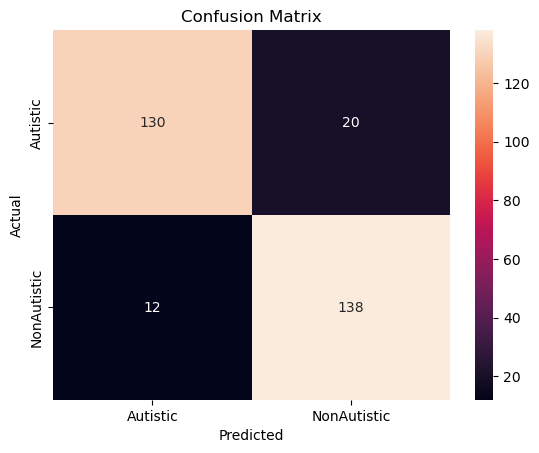

In [37]:
train_model(model, train_loader, val_loader, epochs=5)
y_true, y_pred, y_probs = evaluate(model, test_loader)
class_names = train_data.classes
plot_confusion_and_report([int(y[0]) for y in y_true], [int(y[0]) for y in y_pred], class_names)


In [38]:
torch.save(model.state_dict(), 'asd_resnet18_model.pth')
